<a href="https://colab.research.google.com/github/zs2770-rgb/Hello-World/blob/main/final_report_submission.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Final Report Submission


## 1. Load Data and Create Target


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load the dataset
whr_df = pd.read_csv('/content/WHR_2023.csv')

# Inspect the first few rows to understand the structure
whr_df.head(5)


,country,region,happiness_score,gdp_per_capita,social_support,healthy_life_expectancy,freedom_to_make_life_choices,generosity,perceptions_of_corruption
0,Finland,Western Europe,7.804,1.888,1.585,0.535,0.772,0.126,0.535
1,Denmark,Western Europe,7.586,1.949,1.548,0.537,0.734,0.208,0.525
2,Iceland,Western Europe,7.530,1.926,1.620,0.559,0.738,0.250,0.187
3,Israel,Middle East and North Africa,7.473,1.833,1.521,0.577,0.569,0.124,0.158
4,Netherlands,Western Europe,7.403,1.942,1.488,0.545,0.672,0.251,0.394


In [ ]:
# Convert the regression target ('happiness_score') into classification labels
# We'll use quartiles to create 4 happiness categories: Very Low, Low, High, Very High

# Define quartiles
whr_df['happiness_category'] = pd.qcut(whr_df['happiness_score'],
                                       q=5,
                                       labels=['Very Low', 'Low','Average', 'High', 'Very High'])

# Select features and target
X = whr_df.drop(columns=['happiness_score', 'happiness_category'])
y = whr_df['happiness_category']

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Convert y_train and y_test to numerical labels
y_train_labels = y_train.astype('category').cat.codes
# y_test_labels = ## Complete in a similar manner as above.
y_test_labels = y_test.astype('category').cat.codes

In [ ]:
# Truncated and cleaned up region data to merge
countrydata=pd.read_csv("/content/newcountryvars.csv")

countrydata.head()

,country_name,population,population_below_poverty_line,hdi,life_expectancy,expected_years_of_schooling,mean_years_of_schooling,gni
0,India,1339180127,21.9,0.623559,68.322,11.696590,6.298834,5663.474799
1,Nigeria,190886311,70.0,0.527105,53.057,9.970482,6.000000,5442.901264
2,Mexico,129163276,46.2,0.761683,76.972,13.299090,8.554985,16383.106680
3,Pakistan,197015955,29.5,0.550354,66.365,8.106910,5.089460,5031.173074
4,Bangladesh,164669751,31.5,0.578824,71.985,10.178706,5.241577,3341.490722


In [ ]:
# Merge in new data to X_train and X_test by taking "country" from first table and "country_name" from 2nd table.
# Also check which countries are common in both the datasets, and which type of merge will you perform for the best results.
# Hint: Look on the 'how' parameter of megre function of pandas.


X_train = pd.merge(X_train, countrydata, left_on='country', right_on='country_name', how='left').drop(columns=['country_name'])
X_test = pd.merge(X_test, countrydata, left_on='country', right_on='country_name', how='left').drop(columns=['country_name'])


## 2. Relevant Visualization

We kept one main EDAV figure that directly shows how the strongest features shift across happiness categories.


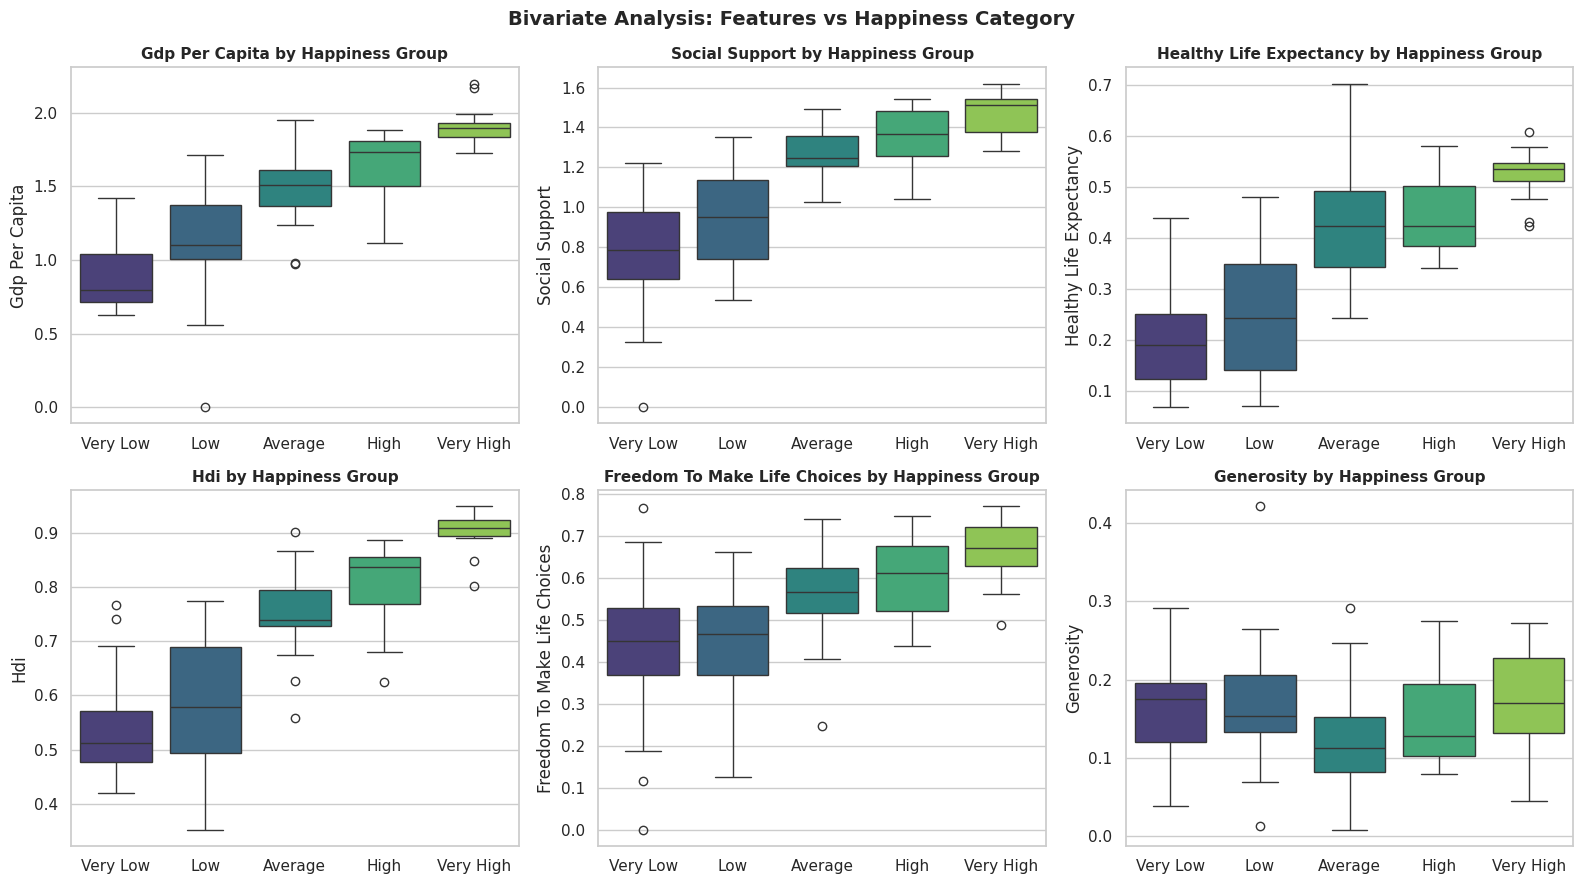

In [ ]:
# Your plotting code(s) here:
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1) Combine X_train + y_train into one DataFrame for stable plotting
whr_train = X_train.copy()
whr_train["happiness_category"] = y_train.values

# 2) Features to plot
features_to_plot = [
    "gdp_per_capita",
    "social_support",
    "healthy_life_expectancy",
    "hdi",
    "freedom_to_make_life_choices",
    "generosity",
]
# 3) Set category order
desired_order = ["Very Low", "Low", "Average", "High", "Very High"]
actual_cats = pd.Series(whr_train["happiness_category"]).dropna().unique().tolist()
order = [c for c in desired_order if c in actual_cats]

# 4) Plot the graphs
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, feat in enumerate(features_to_plot):
    if feat not in whr_train.columns:
        continue

    sns.boxplot(
        data=whr_train,
        x="happiness_category",
        y=feat,
        order=order,
        ax=axes[i],
        palette="viridis",
    )
    axes[i].set_title(f"{feat.replace('_', ' ').title()} by Happiness Group", fontsize=11, fontweight="bold")
    axes[i].set_xlabel("")
    axes[i].set_ylabel(feat.replace("_", " ").title())

plt.suptitle("Bivariate Analysis: Features vs Happiness Category", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 3. Feature Engineering and Preprocessing


In [ ]:
# Your code here:

interaction_pairs = [
    ("gdp_per_capita", "healthy_life_expectancy", "gdp_health_interaction"),
    ("social_support", "freedom_to_make_life_choices", "support_freedom_interaction"),
]

for a, b, new_name in interaction_pairs:
    if a in X_train.columns and b in X_train.columns:
        X_train[new_name] = X_train[a] * X_train[b]
        X_test[new_name]  = X_test[a] * X_test[b]

In [ ]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer, make_column_transformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Create the preprocessing pipelines for both numeric and categorical data.
# 1. Identify numerical features by dropping non-numerical ones
numeric_features = X_train.select_dtypes(include="number").columns
numeric_features = numeric_features.tolist()

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')), # Changed from constant 0 to median for better data accuracy
    ('scaler', StandardScaler())])

# 2. Identify categorical features
categorical_list = ['region','sub-region']
categorical_features = [col for col in categorical_list if col in X_train.columns]

#Replacing missing values with mode value and then one hot encoding.
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# 3. Final preprocessor object set up with ColumnTransformer
preprocessor = ColumnTransformer(transformers=[('num', numeric_transformer, numeric_features),('cat', categorical_transformer, categorical_features)])


# 4. Fit your preprocessor object
preprocess = preprocessor.fit(X_train)

## 4. Best Classical Models

We only keep tuned Random Forest and KNN because they demonstrated the best results.


In [ ]:
# Submit a third model using GridSearchCV

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
import numpy as np

param_grid = {"n_estimators": np.arange(50, 301, 50),
              "max_depth": np.arange(3, 25, 5)}# Use np.arange to create a sequence of numbers for each parameter's space you think should be searched:

# Create a RandomForestClassifier object
model_3 = RandomForestClassifier(random_state=22)

gridmodel = GridSearchCV(
    estimator=model_3,
    param_grid=param_grid,
    scoring="accuracy",
    cv=5)
    # Read GridSearchCV docs and create an object with RandomForestClassifier as the model

#Fit the GridSearchCV object to the preprocessed training data:
X_train_t = preprocess.transform(X_train)
gridmodel.fit(X_train_t, y_train)

#extract best score and parameter by calling objects "best_score_" and "best_params_"
print("best mean cross-validation score: {:.3f}".format(gridmodel.best_score_))
print("best parameters: {}".format(gridmodel.best_params_))

# Make predictions using the best model :
X_test_t = preprocessor(X_test)
pred_best = gridmodel.predict(X_test_t)

best mean cross-validation score: 0.579
best parameters: {'max_depth': np.int64(3), 'n_estimators': np.int64(150)}


In [ ]:
#Submit Model 3:
model_3 = RandomForestClassifier(n_estimators=150, max_depth=3, random_state=22)

model_3.fit(X_train_t, y_train)

#-- Generate predicted values

prediction_labels = model_3.predict(preprocessor(X_test))

## Write lines of code to show model performance by comparing prediction_labels with true labels:
print("Model 3 Accuracy:", accuracy_score(y_test, prediction_labels))

Model 3 Accuracy: 0.5714285714285714


In [ ]:

model_knn = KNeighborsClassifier(n_neighbors=5)

model_knn.fit(preprocessor(X_train), y_train)

# Generate predicted values
prediction_labels = model_knn.predict(preprocessor(X_test))

# Evaluate model performance
print("Accuracy for KNN:", accuracy_score(y_test, prediction_labels))

Accuracy for KNN: 0.5714285714285714


## 5. Best Overall Model

The regularized neural network gave the strongest test performance, so we kept the original training/evaluation code and its learning-curve visualizations.


In [ ]:
import keras
from keras.models import Sequential
from keras.layers import Dense, Activation, Dropout, BatchNormalization
from keras.utils import to_categorical

# Preprocess input features
X_train_t = preprocessor(X_train)
X_test_t = preprocessor(X_test)

# Count features in input data
feature_count = X_train_t.shape[1]
print(f"Number of features: {feature_count}")

# Encode categorical labels to one-hot encoding
y_train_onehot = to_categorical(y_train_labels)
y_test_onehot = to_categorical(y_test_labels)

# Define number of output classes
num_classes = y_train_onehot.shape[1]


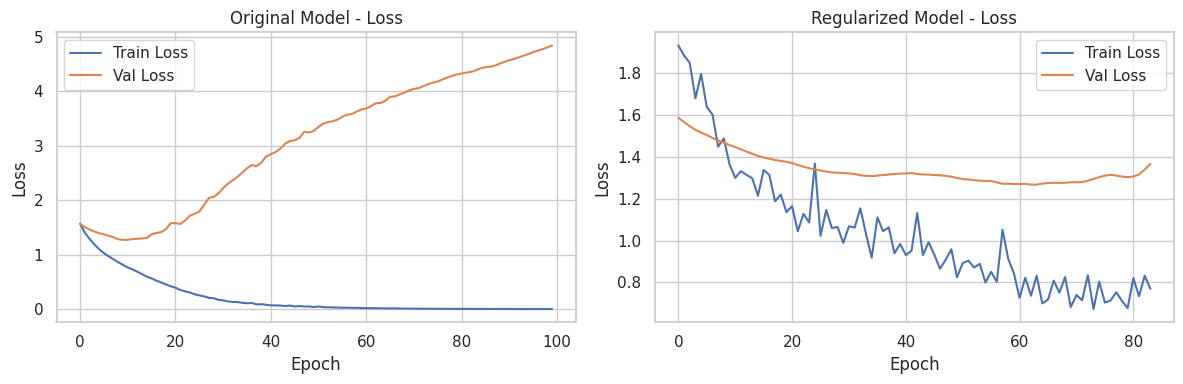

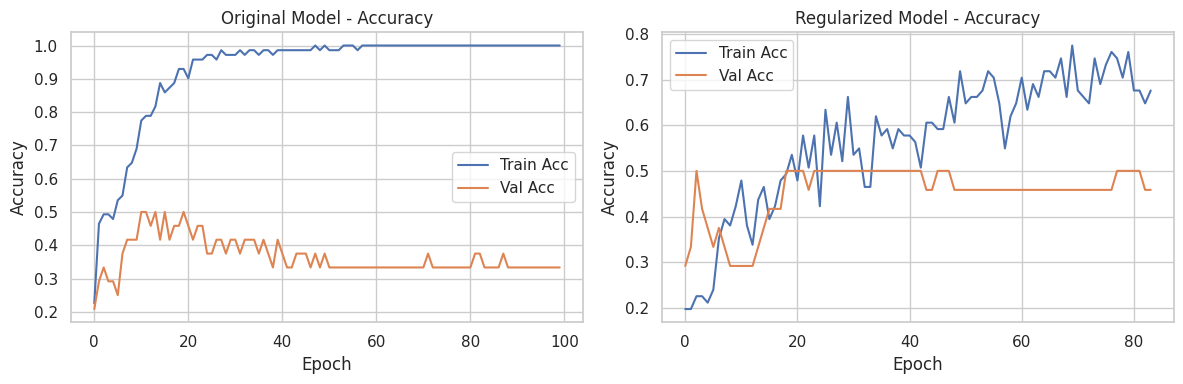

Original Model - Final Validation Accuracy: 0.3333
Regularized Model - Final Validation Accuracy: 0.4583
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step

Original Model - Test Accuracy: 0.4762
Regularized Model - Test Accuracy: 0.6429


In [ ]:
# Write your lines of code here:
from keras.models import Sequential
from keras.layers import Dense, Dropout, BatchNormalization, Activation
from keras.callbacks import EarlyStopping
from keras.optimizers import Adam
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
import numpy as np

# Original model (without regularization)
original_model = Sequential([
    Dense(128, input_dim=X_train_t.shape[1], activation='relu'),
    Dense(64, activation='relu'),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(len(np.unique(y_train_labels)), activation='softmax')
])

original_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train original model
history_original = original_model.fit(
    X_train_t, y_train_onehot,
    batch_size=20, epochs=100,
    validation_split=0.25, verbose=0
)

# Regularized model (with Dropout and Batch Normalization)
regularized_model = Sequential([
    Dense(128, input_dim=X_train_t.shape[1]),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.3),

    Dense(64),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.3),

    Dense(64),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.3),

    Dense(32),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.2),

    Dense(len(np.unique(y_train_labels)), activation='softmax')
])

regularized_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train regularized model with early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

history_regularized = regularized_model.fit(
    X_train_t, y_train_onehot,
    batch_size=20, epochs=100,
    validation_split=0.25,
    callbacks=[early_stop],
    verbose=0
)

# Compare performance
# Plot training vs validation loss
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_original.history['loss'], label='Train Loss')
plt.plot(history_original.history['val_loss'], label='Val Loss')
plt.title('Original Model - Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_regularized.history['loss'], label='Train Loss')
plt.plot(history_regularized.history['val_loss'], label='Val Loss')
plt.title('Regularized Model - Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# Plot accuracy comparison
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_original.history['accuracy'], label='Train Acc')
plt.plot(history_original.history['val_accuracy'], label='Val Acc')
plt.title('Original Model - Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_regularized.history['accuracy'], label='Train Acc')
plt.plot(history_regularized.history['val_accuracy'], label='Val Acc')
plt.title('Regularized Model - Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

# Print final validation accuracy
print(f"Original Model - Final Validation Accuracy: {history_original.history['val_accuracy'][-1]:.4f}")
print(f"Regularized Model - Final Validation Accuracy: {history_regularized.history['val_accuracy'][-1]:.4f}")

# Test on test set
orig_pred = original_model.predict(X_test_t)
orig_pred_labels = [unique_categories[i] for i in np.argmax(orig_pred, axis=1)]

reg_pred = regularized_model.predict(X_test_t)
reg_pred_labels = [unique_categories[i] for i in np.argmax(reg_pred, axis=1)]

print(f"\nOriginal Model - Test Accuracy: {accuracy_score(y_test, orig_pred_labels):.4f}")
print(f"Regularized Model - Test Accuracy: {accuracy_score(y_test, reg_pred_labels):.4f}")

## 6. Key Insights and Observed Behaviors

- The feature visualization suggests that countries in higher happiness groups generally have higher GDP per capita, stronger social support, longer healthy life expectancy, and better HDI.
- Among the classical models, both the tuned Random Forest and KNN reached **0.5714** test accuracy, which made them the best traditional ML performers in our notebook.
- The regularized neural network performed best overall with **0.6429** test accuracy, improving over the original neural network.
- The regularization results suggest that dropout, batch normalization, and early stopping helped reduce overfitting and improved generalization on the test set.
- Overall, the final pattern in our notebook was that stronger preprocessing plus regularization mattered more than simply trying more complex models without control for overfitting.
